# Imports

In [1]:
import shap
import optuna
import xgboost
import lightgbm
import lime.lime_tabular

import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

from sklearn.model_selection import (
train_test_split,
KFold,
StratifiedKFold,
cross_val_score
)

from sklearn.metrics import (
accuracy_score,
roc_auc_score,
classification_report,
confusion_matrix,
precision_recall_curve,
f1_score,
precision_score,
recall_score,
precision_recall_fscore_support,
average_precision_score,
brier_score_loss
)

import warnings
warnings.filterwarnings('ignore')

print("---Imports Completed---")

---Imports Completed---


# Data loading

In [2]:
train = pd.read_csv('/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv')
test = pd.read_csv('/kaggle/input/competitions/GiveMeSomeCredit/cs-test.csv')

train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
train.drop(['Unnamed: 0'], axis=1, inplace=True)

print("="*20)
print(train.shape)
print("="*20)
print(train.info())
print("="*20)
print(train.dtypes.value_counts())
print("="*20)
print(train.isnull().sum())
print("="*20)
print(train.describe())
print("="*20)
print(train.duplicated().sum())

(150000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  

In [4]:
test.drop(['Unnamed: 0','SeriousDlqin2yrs'], axis=1, inplace=True)

print("="*20)
print(test.shape)
print("="*20)
print(test.info())
print("="*20)
print(test.dtypes.value_counts())
print("="*20)
print(test.isnull().sum())
print("="*20)
print(test.describe())
print("="*20)
print(test.duplicated().sum())

(101503, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 10 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 1   age                                   101503 non-null  int64  
 2   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 3   DebtRatio                             101503 non-null  float64
 4   MonthlyIncome                         81400 non-null   float64
 5   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 6   NumberOfTimes90DaysLate               101503 non-null  int64  
 7   NumberRealEstateLoansOrLines          101503 non-null  int64  
 8   NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 9   NumberOfDependents                    98877 non-null   float64
dtypes: float64(4), int64(6)
memory usage: 7.7 MB
None
int64

In [5]:
print("Null values and Counts.")

nulls = train.isnull().sum()
null_percent = (nulls / len(train)) * 100
null_df = pd.DataFrame({
    "Null count": nulls,
    "Null percentage":null_percent
}).sort_values('Null percentage', ascending=False)
print(null_df[null_df['Null count'] > 0])

print("="*20)

print("Null values and Counts in Test data.")

nulls_test = test.isnull().sum()
null_percent_test = (nulls / len(test)) * 100
null_df_test = pd.DataFrame({
    "Null count": nulls_test,
    "Null percentage":null_percent_test
}).sort_values('Null percentage', ascending=False)
print(null_df_test[null_df_test['Null count'] > 0])

Null values and Counts.
                    Null count  Null percentage
MonthlyIncome            29731        19.820667
NumberOfDependents        3924         2.616000
Null values and Counts in Test data.
                    Null count  Null percentage
MonthlyIncome          20103.0        29.290760
NumberOfDependents      2626.0         3.865896


# Model based imputation

In [6]:
def cat_imputation(df: pd.DataFrame, n_iterations: int = 3, random_state: int = 42) -> pd.DataFrame:
    
    df_imputed = df.copy()

    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    null_masks = {col: df[col].isna() for col in df.columns if df[col].isna().any()}
    missing_cols = list(null_masks.keys())

    if not missing_cols:
        print("No Missing columns exist.")
        return df_imputed
    else:
        print(f"Columns to impute: {missing_cols}")
        print(f"Categorical cols: {cat_cols}")
        print(f"Numeric cols: {num_cols}")


    for col in missing_cols:
        if col in cat_cols:
            df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])
        elif col in num_cols:
            df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())
        else:
            print(f"Skipping {col}: Unsupported type {df[col].dtype}")

    for iteration in range(n_iterations):
        print(f"\n── Iteration {iteration + 1}/{n_iterations} ──")

        for target_col in missing_cols:
            if target_col not in cat_cols and target_col not in num_cols:
                continue

            mask = null_masks[target_col]
            if mask.sum() == 0:
                continue

            feature_cols = [c for c in df_imputed.columns if c != target_col]

            cat_features_idx = [
                i for i, c in enumerate(feature_cols) if c in cat_cols
            ]

            X_train = df_imputed.loc[~mask, feature_cols].copy().reset_index(drop=True)
            y_train = df_imputed.loc[~mask, target_col].copy().reset_index(drop=True)
            X_pred = df_imputed.loc[mask, feature_cols].copy().reset_index(drop=True)

            for fc in feature_cols:
                if fc in cat_cols:
                    X_train[fc] = X_train[fc].astype(str).fillna("MISSING")
                    X_pred[fc] = X_pred[fc].astype(str).fillna("MISSING")
                elif fc in num_cols:
                    _med = X_train[fc].median()
                    X_train[fc] = X_train[fc].fillna(_med)
                    X_pred[fc] = X_pred[fc].fillna(_med)

            if target_col in cat_cols:
                y_train = y_train.astype(str)
                model = XGBClassifier(
                    iterations=200, depth=6, learning_rate=0.1,
                    random_seed=random_state, verbose=0,
                    devices='cuda', tree_method='hist'
            )
                model.fit(X_train, y_train)
                preds = model.predict(X_pred).flatten()

            else:
                model = XGBRegressor(
                        iterations=200, depth=6, learning_rate=0.1,
                        random_seed=random_state, verbose=0,
                        devices='cuda', tree_method='hist'
                )
                model.fit(X_train, y_train)
                preds = model.predict(X_pred)

            df_imputed.loc[mask, target_col] = preds
            print(f"{target_col} = {mask.sum()} values imputed ({type(model).__name__})")
    

    return df_imputed

In [7]:
df = cat_imputation(train, n_iterations=1)
print(df.info())
print("="*20)
df_test = cat_imputation(test, n_iterations=1)
print(df_test.info())

Columns to impute: ['MonthlyIncome', 'NumberOfDependents']
Categorical cols: []
Numeric cols: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

── Iteration 1/1 ──
MonthlyIncome = 29731 values imputed (XGBRegressor)
NumberOfDependents = 3924 values imputed (XGBRegressor)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDu

# Feature engineering

In [8]:
df["TotalLatePayments"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"] +
    df["NumberOfTime60-89DaysPastDueNotWorse"] +
    df["NumberOfTimes90DaysLate"]
)

df["SevereLateRatio"] = df["NumberOfTimes90DaysLate"] / (df["TotalLatePayments"] + 1)

df["HighUtilization"] = (df["RevolvingUtilizationOfUnsecuredLines"] > 0.8).astype(int)
df["LowUtilization"] = (df["RevolvingUtilizationOfUnsecuredLines"] < 0.3).astype(int)

df["IncomeToDebt"] = df["MonthlyIncome"] / (df["DebtRatio"] + 1)
df["DebtPerPerson"] = df["DebtRatio"] / (df["NumberOfDependents"] + 1)

df["IncomePerDependent"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)

df["LoanDensity"] = df["NumberOfOpenCreditLinesAndLoans"] / (df["age"] + 1)
df["RealEstateRatio"] = df["NumberRealEstateLoansOrLines"] / (df["NumberOfOpenCreditLinesAndLoans"] + 1)

df["HasLatePayment"] = (df["TotalLatePayments"] > 0).astype(int)
df["HighDebt"] = (df["DebtRatio"] > 1).astype(int)
df["LowIncome"] = (df["MonthlyIncome"] < df["MonthlyIncome"].median()).astype(int)


df_test["TotalLatePayments"] = (
    df_test["NumberOfTime30-59DaysPastDueNotWorse"] +
    df_test["NumberOfTime60-89DaysPastDueNotWorse"] +
    df_test["NumberOfTimes90DaysLate"]
)

df_test["SevereLateRatio"] = df_test["NumberOfTimes90DaysLate"] / (df_test["TotalLatePayments"] + 1)

df_test["HighUtilization"] = (df_test["RevolvingUtilizationOfUnsecuredLines"] > 0.8).astype(int)
df_test["LowUtilization"] = (df_test["RevolvingUtilizationOfUnsecuredLines"] < 0.3).astype(int)

df_test["IncomeToDebt"] = df_test["MonthlyIncome"] / (df_test["DebtRatio"] + 1)
df_test["DebtPerPerson"] = df_test["DebtRatio"] / (df_test["NumberOfDependents"] + 1)

df_test["IncomePerDependent"] = df_test["MonthlyIncome"] / (df_test["NumberOfDependents"] + 1)

df_test["LoanDensity"] = df_test["NumberOfOpenCreditLinesAndLoans"] / (df_test["age"] + 1)
df_test["RealEstateRatio"] = df_test["NumberRealEstateLoansOrLines"] / (df_test["NumberOfOpenCreditLinesAndLoans"] + 1)

df_test["HasLatePayment"] = (df_test["TotalLatePayments"] > 0).astype(int)
df_test["HighDebt"] = (df_test["DebtRatio"] > 1).astype(int)
df_test["LowIncome"] = (df_test["MonthlyIncome"] < df_test["MonthlyIncome"].median()).astype(int)

In [9]:
print(df.info())
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 23 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         150000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    150000 non-null  float64
 11  

# EDA

In [10]:
def hist_plotter(data:pd.DataFrame):

    print("Histogram plot...")
    
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    n_features = len(num_cols)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*3))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.histplot(
            data=data,
            kde=True,
            ax=axes[i],
            x=col,
            bins=20
        )
        axes[i].set_title(f"Distribution of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('count')

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

def box_plotter(data:pd.DataFrame):

    print("Box plot...")
    
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    n_features = len(num_cols)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*3))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.boxplot(
            data=data,
            ax=axes[i],
            y=col
        )
        axes[i].set_title(f"Box plot of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('count')

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

def violin_plotter(data:pd.DataFrame):

    print("Violin plot...")
    
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    n_features = len(num_cols)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*3))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.violinplot(
            data=data,
            ax=axes[i],
            y=col
        )
        axes[i].set_title(f"Violin plot of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('count')

    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

Histogram plot...


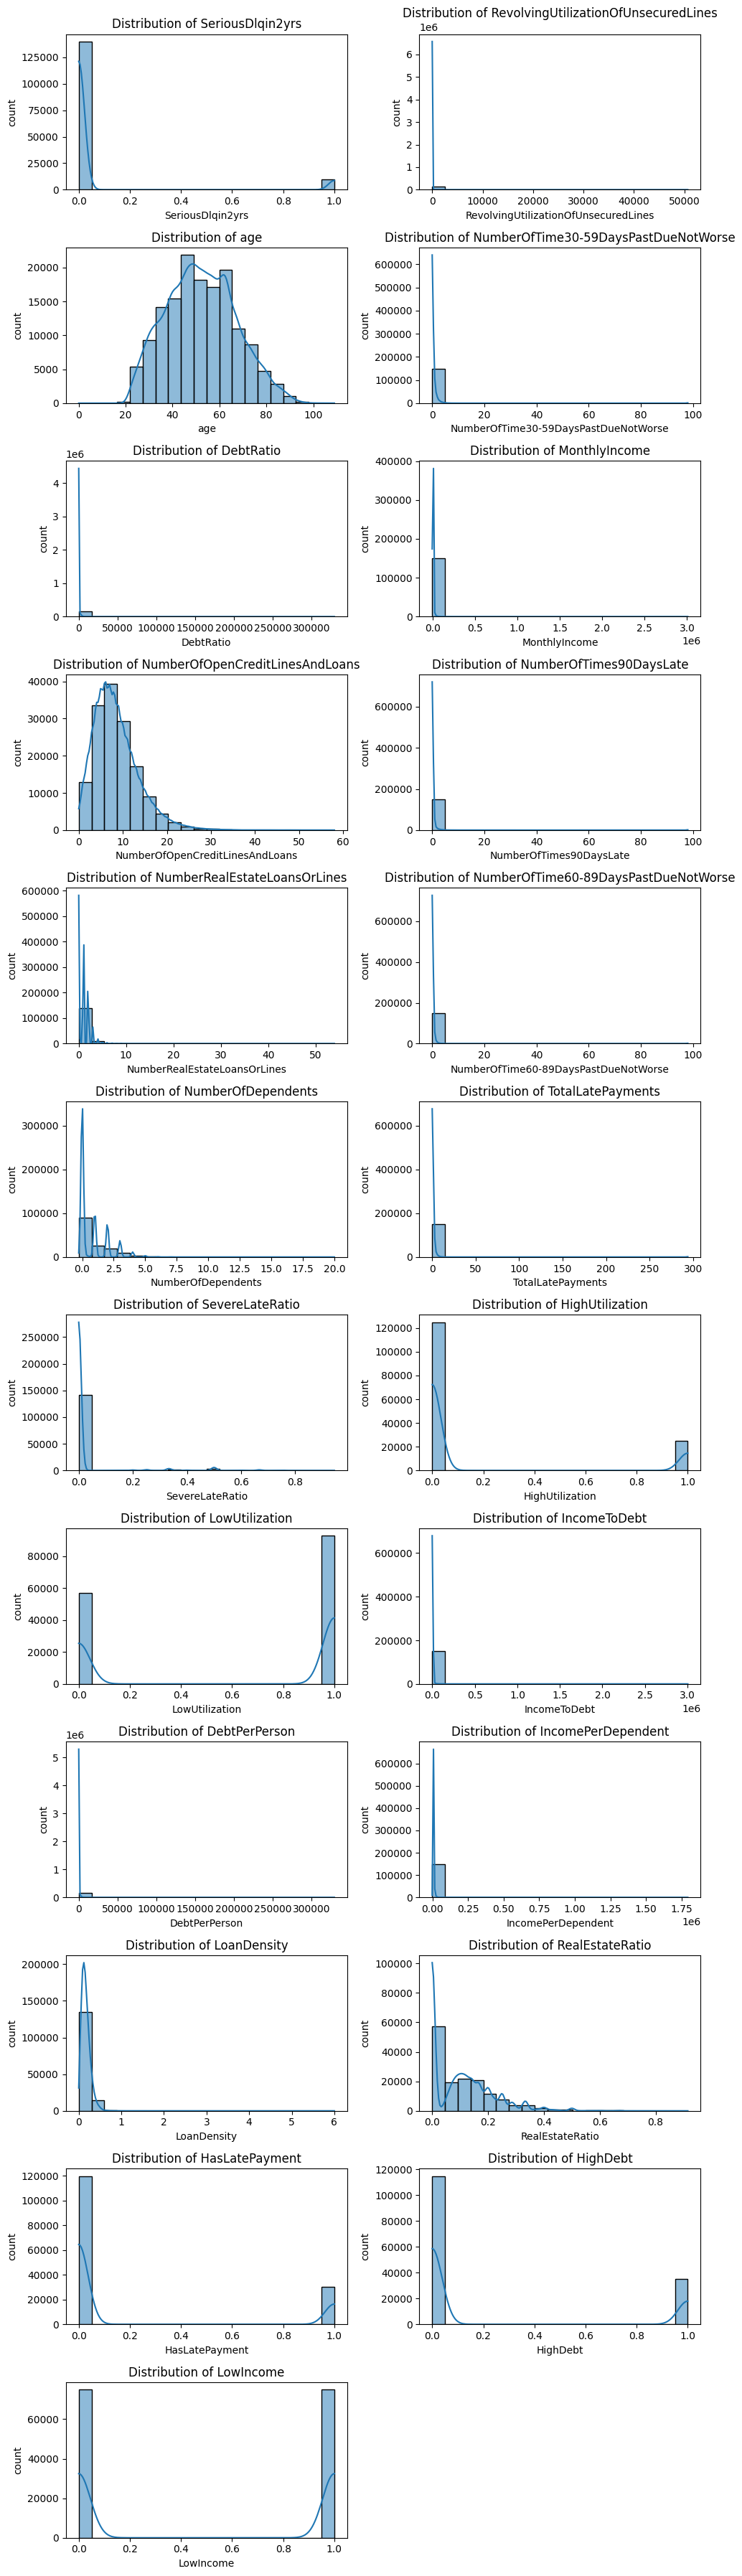

Box plot...


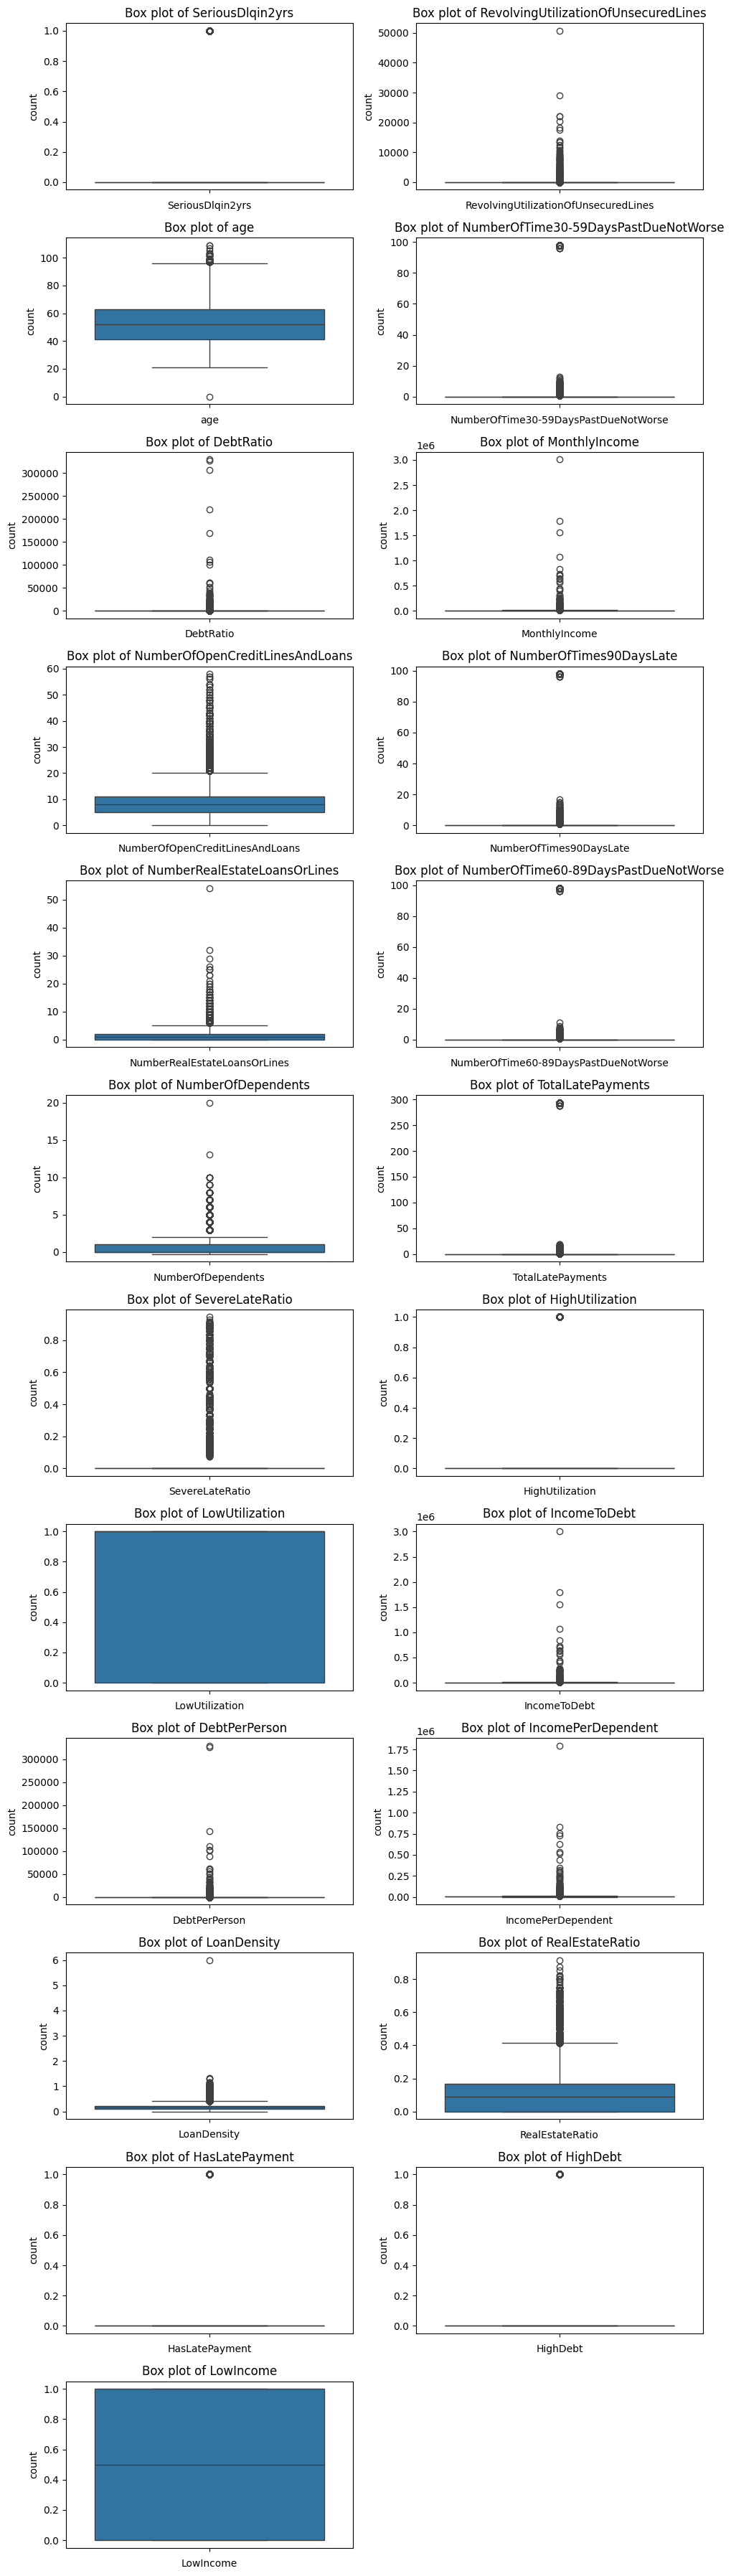

Violin plot...


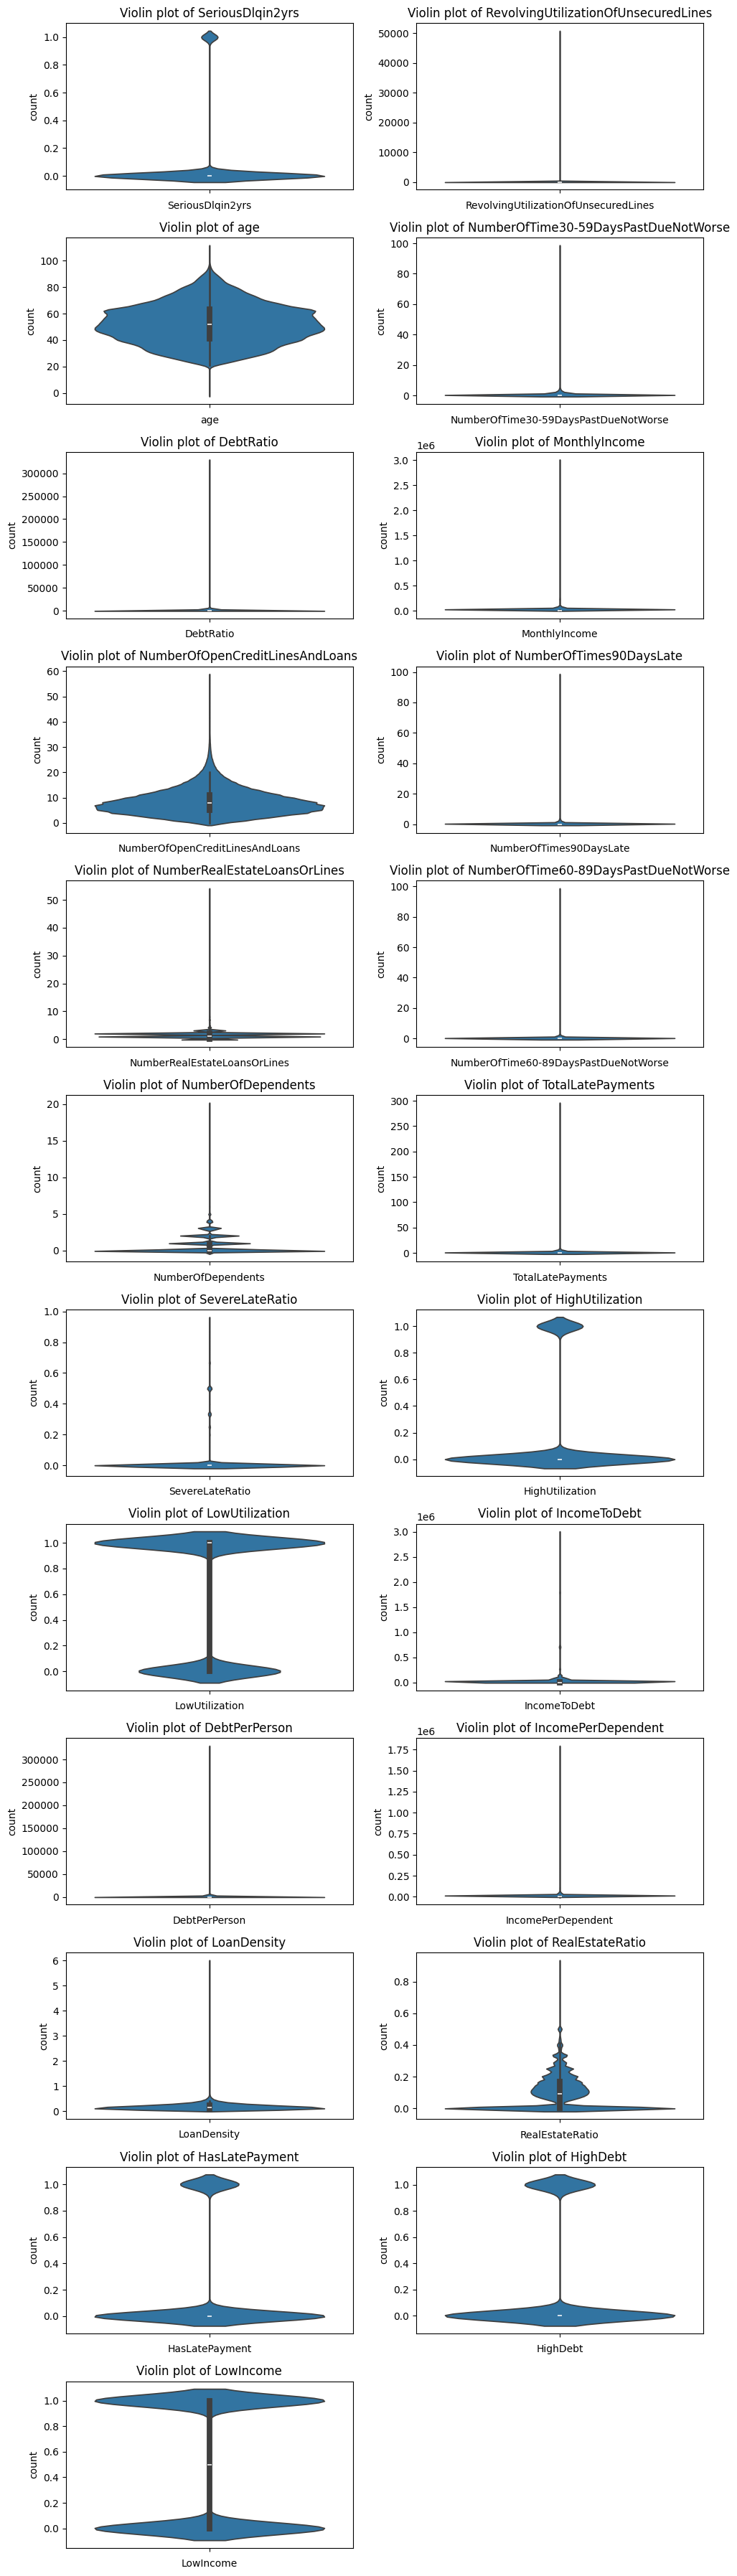

In [11]:
hist_plotter(data=df)
box_plotter(data=df)
violin_plotter(data=df)

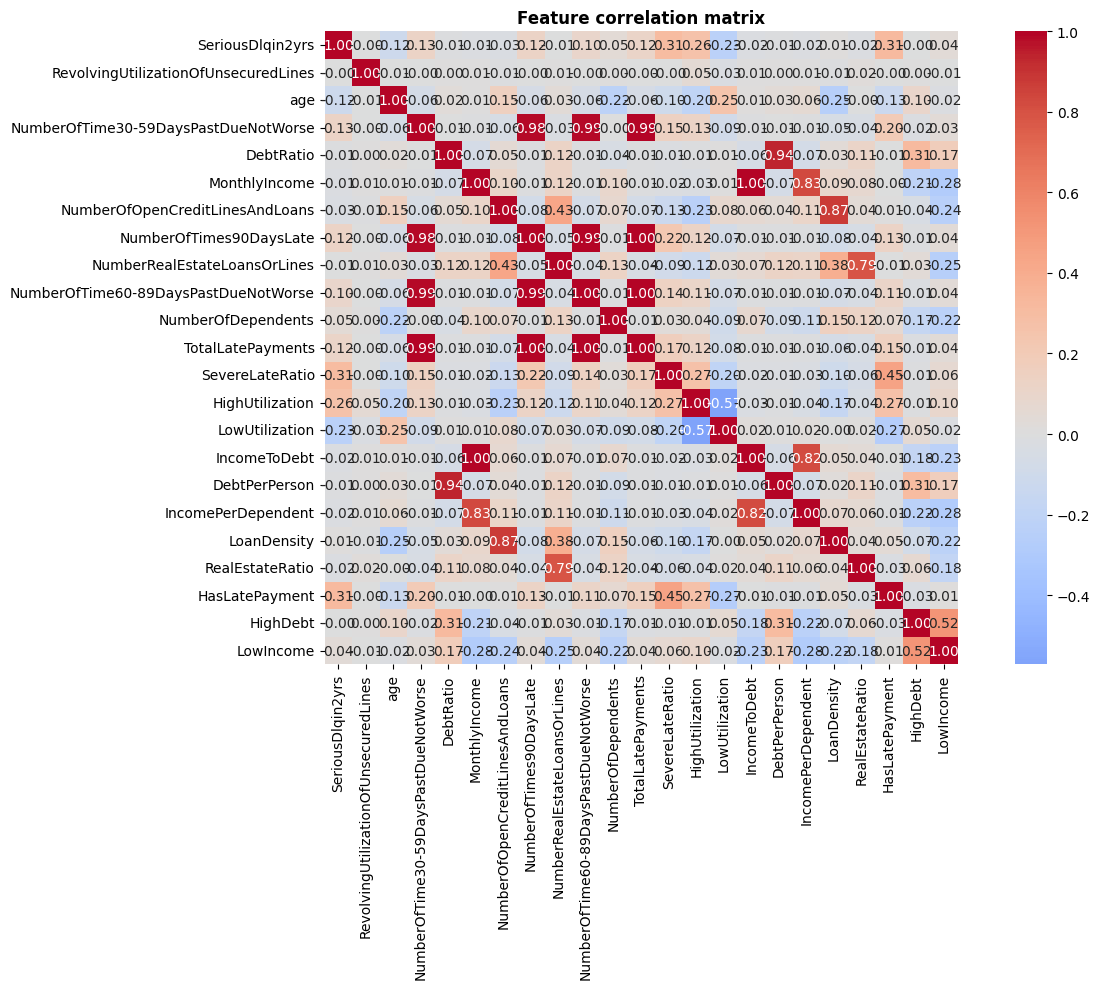


 Top correlation features with Target.

HasLatePayment                          0.314407
SevereLateRatio                         0.306396
HighUtilization                         0.258607
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
TotalLatePayments                       0.115513
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.047426
LowIncome                               0.039027
LoanDensity                             0.012320
Name: SeriousDlqin2yrs, dtype: float64


In [12]:
plt.figure(figsize=(14,10))

numerics = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numerics].corr()

sns.heatmap(
    data=correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title('Feature correlation matrix', fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = correlation_matrix['SeriousDlqin2yrs'].sort_values(ascending=False)
print("\n Top correlation features with Target.\n")
print(target_corr[1:11])

In [13]:
df['SeriousDlqin2yrs'].astype(int)

0         1
1         0
2         0
3         0
4         0
         ..
149995    0
149996    0
149997    0
149998    0
149999    0
Name: SeriousDlqin2yrs, Length: 150000, dtype: int64

# Training Baseline Models

In [14]:
X = df.drop(['SeriousDlqin2yrs'], axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120000, 22)
(30000, 22)
(120000,)
(30000,)


In [15]:
baseline = {
    'Logistic Regression': Pipeline([
        ('scaler', RobustScaler(
            with_scaling=True,
            with_centering=True
        )),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]),

    'Decision Tree': Pipeline([
        ('model', DecisionTreeClassifier(
            class_weight='balanced',
            random_state=42
        ))
    ]),

    'Random Forest': Pipeline([
        ('model', RandomForestClassifier(
            class_weight='balanced',
            random_state=42, n_jobs=-1
        ))
    ]),
    

    'Hist Gradient Boosting': Pipeline([
        ('model', HistGradientBoostingClassifier(
            class_weight='balanced',
            random_state=42
        ))
    ])
}

results = {}

for name, pipe in baseline.items():

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)
    prfs = precision_recall_fscore_support(y_test, y_pred)

    results[name] = {
        "Accuracy Score": acc,
        "ROC-AUC": roc,
        "Confusion matrix": cm,
        "Classification report": cr,
        "Precision Recall fscore": prfs
    }

    print(f"{name} Accuracy score = {acc:.4f}")
    print(f"{name} ROC AUC = {roc:.4f}")
    print(f"{name} Confusion matrix =\n {cm} ")
    print(f"{name} Classification report = \n {cr}")
    print(f"{name} Precision Recall fscore = \n {prfs}")
    print("="*40)

Logistic Regression Accuracy score = 0.7871
Logistic Regression ROC AUC = 0.8542
Logistic Regression Confusion matrix =
 [[22094  5901]
 [  487  1518]] 
Logistic Regression Classification report = 
               precision    recall  f1-score   support

           0       0.98      0.79      0.87     27995
           1       0.20      0.76      0.32      2005

    accuracy                           0.79     30000
   macro avg       0.59      0.77      0.60     30000
weighted avg       0.93      0.79      0.84     30000

Logistic Regression Precision Recall fscore = 
 (array([0.9784332 , 0.20460979]), array([0.78921236, 0.75710723]), array([0.87369503, 0.3221562 ]), array([27995,  2005]))
Decision Tree Accuracy score = 0.8993
Decision Tree ROC AUC = 0.5999
Decision Tree Confusion matrix =
 [[26468  1527]
 [ 1495   510]] 
Decision Tree Classification report = 
               precision    recall  f1-score   support

           0       0.95      0.95      0.95     27995
           1       

# OPTUNA 

In [16]:
def objective_xgb(trial, X, y):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",  
        "booster": "gbtree",

        "lambda": trial.suggest_float("lambda", 1e-3, 10, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 10, log=True),

        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "eta": trial.suggest_float("eta", 0.01, 0.2),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),

        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 10),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBClassifier(
            **params,
            n_estimators=500,
            random_state=42,
            verbosity=0, device='cuda', tree_method='hist'
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict_proba(X_val)[:, 1]
        score = average_precision_score(y_val, preds)
        scores.append(score)

    return np.mean(scores)

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(lambda trial: objective_xgb(trial, X, y), n_trials=50)

print("Best params:", study_xgb.best_params)
print("Best score:", study_xgb.best_value)

[I 2026-05-04 04:34:57,466] A new study created in memory with name: no-name-2327bb6a-3b02-4f6e-bfc0-466e2238c4af
[I 2026-05-04 04:35:06,035] Trial 0 finished with value: 0.37667140490267076 and parameters: {'lambda': 0.022957334135648478, 'alpha': 1.859359989830361, 'max_depth': 7, 'eta': 0.10216257453647262, 'subsample': 0.9382556590997787, 'colsample_bytree': 0.7816729219041226, 'min_child_weight': 1, 'gamma': 1.989046837447137, 'scale_pos_weight': 6.576694031813998}. Best is trial 0 with value: 0.37667140490267076.
[I 2026-05-04 04:35:14,741] Trial 1 finished with value: 0.37262642344356206 and parameters: {'lambda': 8.301295714574582, 'alpha': 0.0024046520851799067, 'max_depth': 8, 'eta': 0.1444470538839766, 'subsample': 0.8773801374269428, 'colsample_bytree': 0.8728085314437706, 'min_child_weight': 4, 'gamma': 3.3089823574547363, 'scale_pos_weight': 8.203009510335256}. Best is trial 0 with value: 0.37667140490267076.
[I 2026-05-04 04:35:21,143] Trial 2 finished with value: 0.4050

Best params: {'lambda': 0.7424692680284152, 'alpha': 0.0013266196716296415, 'max_depth': 5, 'eta': 0.022076048779343646, 'subsample': 0.950115690675175, 'colsample_bytree': 0.7191974690491589, 'min_child_weight': 8, 'gamma': 4.99461625672054, 'scale_pos_weight': 2.7403342897399456}
Best score: 0.4069233628718233


In [17]:
def objective_lgb(trial, X, y):
    params = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "boosting_type": "gbdt",

        "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 10, log=True),

        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),

        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),

        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 10),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = LGBMClassifier(
            **params,
            n_estimators=500,
            random_state=42,
            gpu_device_id=0,
            gpu_platform_id=0,
            device='gpu'
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[lightgbm.early_stopping(50)]
        )

        preds = model.predict_proba(X_val)[:, 1]
        score = average_precision_score(y_val, preds)
        scores.append(score)

    return np.mean(scores)


study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(lambda trial: objective_lgb(trial, X, y), n_trials=50)

print("Best params:", study_lgb.best_params)
print("Best score:", study_lgb.best_value)

[I 2026-05-04 04:41:17,665] A new study created in memory with name: no-name-87833fbe-47df-447b-894d-e8a0231d28b5
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[18]	valid_0's auc: 0.858114
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[21]	valid_0's auc: 0.859935
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[22]	valid_0's auc: 0.865259
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[18]	valid_0's auc: 0.855625
Training until validation scores don't improve for 50 rounds


[I 2026-05-04 04:41:33,325] Trial 0 finished with value: 0.3936013954246468 and parameters: {'lambda_l1': 5.510971677482942, 'lambda_l2': 0.11957182058575408, 'num_leaves': 88, 'feature_fraction': 0.6746258001760881, 'bagging_fraction': 0.797411311491541, 'bagging_freq': 4, 'min_child_samples': 68, 'learning_rate': 0.16566347353478475, 'scale_pos_weight': 8.006985627940193}. Best is trial 0 with value: 0.3936013954246468.


Early stopping, best iteration is:
[16]	valid_0's auc: 0.865845
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[16]	valid_0's auc: 0.859227
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[15]	valid_0's auc: 0.862014
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[20]	valid_0's auc: 0.866046
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[9]	valid_0's auc: 0.857128
Training until validation scores don't improve for 50 rounds


[I 2026-05-04 04:41:44,355] Trial 1 finished with value: 0.3966165414726736 and parameters: {'lambda_l1': 2.013983661357911, 'lambda_l2': 0.2674074498678405, 'num_leaves': 111, 'feature_fraction': 0.8435614850106066, 'bagging_fraction': 0.8206835463172334, 'bagging_freq': 4, 'min_child_samples': 78, 'learning_rate': 0.15167770297993444, 'scale_pos_weight': 2.418115357695516}. Best is trial 1 with value: 0.3966165414726736.


...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[33]	valid_0's auc: 0.861647
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[32]	valid_0's auc: 0.864537
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[30]	valid_0's auc: 0.869179
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[39]	valid_0's auc: 0.85897
Training until validation scores don't improve for 50 rounds


[I 2026-05-04 04:57:02,781] Trial 48 finished with value: 0.4021934351843748 and parameters: {'lambda_l1': 0.03816137774234924, 'lambda_l2': 3.022650023341786, 'num_leaves': 50, 'feature_fraction': 0.9466464571713163, 'bagging_fraction': 0.8487048986257361, 'bagging_freq': 2, 'min_child_samples': 83, 'learning_rate': 0.1293034396005144, 'scale_pos_weight': 2.260180904341094}. Best is trial 26 with value: 0.40742684880846786.


Early stopping, best iteration is:
[28]	valid_0's auc: 0.870261
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[256]	valid_0's auc: 0.864084
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[298]	valid_0's auc: 0.865392
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[188]	valid_0's auc: 0.870548
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[137]	valid_0's auc: 0.859579
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[132]	valid_0's auc: 0.869587


[I 2026-05-04 04:57:20,906] Trial 49 finished with value: 0.4047630965771697 and parameters: {'lambda_l1': 9.278504517472184, 'lambda_l2': 0.8391544925483835, 'num_leaves': 29, 'feature_fraction': 0.9218398180546895, 'bagging_fraction': 0.9626396675003616, 'bagging_freq': 1, 'min_child_samples': 95, 'learning_rate': 0.03649709561366393, 'scale_pos_weight': 8.27066664827791}. Best is trial 26 with value: 0.40742684880846786.


Best params: {'lambda_l1': 0.0628272474586151, 'lambda_l2': 3.4563373675454403, 'num_leaves': 45, 'feature_fraction': 0.9050612728929013, 'bagging_fraction': 0.7014221412635188, 'bagging_freq': 1, 'min_child_samples': 82, 'learning_rate': 0.027829608694310955, 'scale_pos_weight': 1.3631351655703376}
Best score: 0.40742684880846786


# Final models

In [18]:
best_params = study_xgb.best_params

xgb = XGBClassifier(
    **best_params,
    objective='binary:logistic',
    eval_metric='aucpr',
    tree_method='hist',
    device='cuda',
    random_state=42
)

xgb.fit(
    X_train, y_train
)

xg_preds = xgb.predict(X_test)
xg_proba = xgb.predict_proba(X_test)[:,1]

best_params_lgb = study_lgb.best_params

lgbm = LGBMClassifier(
    **best_params_lgb,
    objective='binary',
    device='gpu',
    gpu_platform_id=0,
    gpu_device_id=0,
    random_state=42
)

lgbm.fit(X_train, y_train)
lgbm_preds = lgbm.predict(X_test)
lgbm_proba = lgbm.predict_proba(X_test)[:,1]

# Evaluation

In [19]:
final_proba = 0.4 * xg_proba + 0.6 * lgbm_proba

In [20]:
def evaluate_model(name, y_true, y_proba, threshold=0.5, plot_curves=True):

    y_pred = (y_proba >= threshold).astype(int)

    print(f"\n===={name} (Threshold = {threshold})====")

    acc = accuracy_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_proba)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_proba)

    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")

    print("\n Classification report \n")
    print(classification_report(y_true, y_pred))

    print("Confusion matrix \n")
    print(confusion_matrix(y_true, y_pred))

    if plot_curves:
        from sklearn.metrics import roc_curve, precision_recall_curve

        fpr, tpr, _ = roc_curve(y_true, y_proba)

        precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_proba)

        plt.figure(figsize=(12,6))

        plt.subplot(1, 2, 1)
        plt.plot(fpr, tpr)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")

        plt.subplot(1, 2, 2)
        plt.plot(recall_vals, precision_vals)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve")

        plt.tight_layout()
        plt.show()


====xgb (Threshold = 0.2)====
Accuracy: 0.8809
ROC-AUC: 0.8683
Precision: 0.3103
Recall: 0.6394
F1: 0.4179
PR-AUC: 0.4039

 Classification report 

              precision    recall  f1-score   support

           0       0.97      0.90      0.93     27995
           1       0.31      0.64      0.42      2005

    accuracy                           0.88     30000
   macro avg       0.64      0.77      0.68     30000
weighted avg       0.93      0.88      0.90     30000

Confusion matrix 

[[25146  2849]
 [  723  1282]]


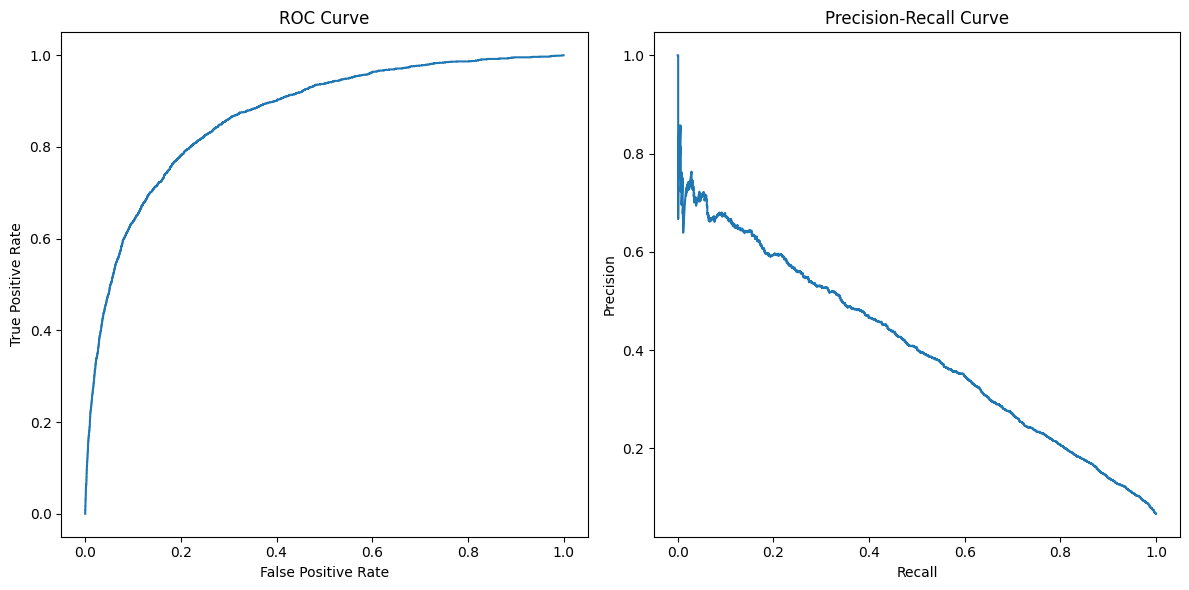


====lgbm (Threshold = 0.2)====
Accuracy: 0.8809
ROC-AUC: 0.8683
Precision: 0.3103
Recall: 0.6394
F1: 0.4179
PR-AUC: 0.4039

 Classification report 

              precision    recall  f1-score   support

           0       0.97      0.90      0.93     27995
           1       0.31      0.64      0.42      2005

    accuracy                           0.88     30000
   macro avg       0.64      0.77      0.68     30000
weighted avg       0.93      0.88      0.90     30000

Confusion matrix 

[[25146  2849]
 [  723  1282]]


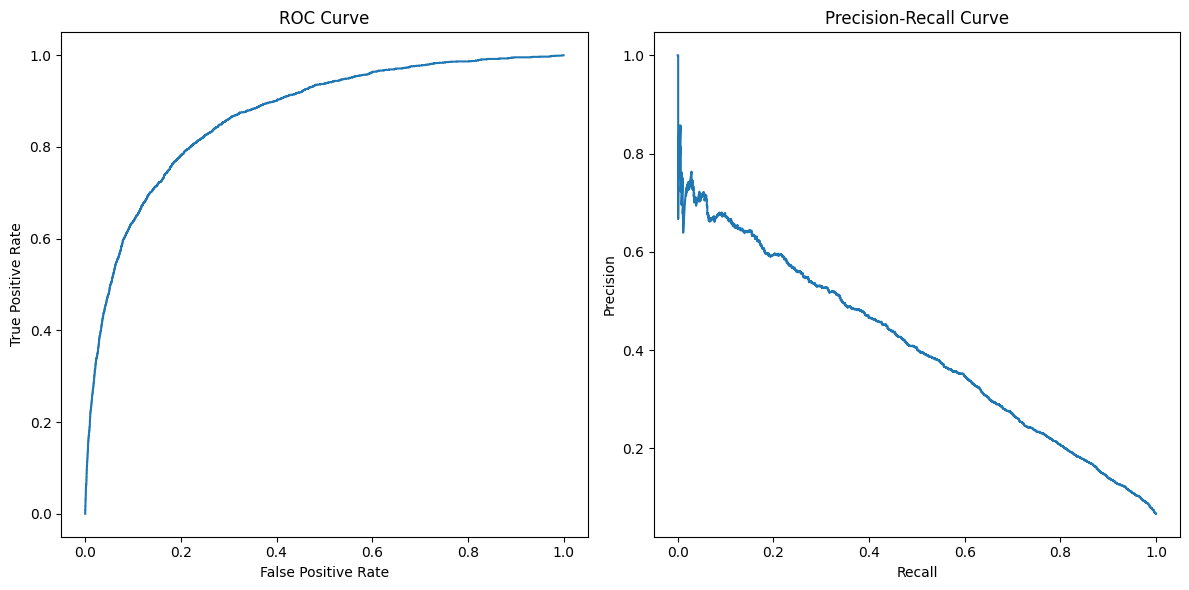

In [21]:
evaluate_model("xgb", y_true=y_test, y_proba=final_proba, threshold=0.2, plot_curves=True)
evaluate_model("lgbm", y_true=y_test, y_proba=final_proba, threshold=0.2, plot_curves=True)

# Optimal Thershold

In [22]:
def find_best_thershold(y_true, y_proba, min_precision=0.25):
    
    thersholds = np.linspace(0.05, 0.9, 100)

    best_t, best_recall = 0.5, 0

    for t in thersholds:
        preds = (y_proba >= t).astype(int)

        precision = precision_score(y_true, preds)
        recall = recall_score(y_true, preds)
        if precision >= min_precision and recall > best_recall:
            best_recall = recall
            best_t = t

    return best_t


====Final Ensemble (Threshold = 0.15303030303030302)====
Accuracy: 0.8421
ROC-AUC: 0.8683
Precision: 0.2559
Recall: 0.7142
F1: 0.3768
PR-AUC: 0.4039

 Classification report 

              precision    recall  f1-score   support

           0       0.98      0.85      0.91     27995
           1       0.26      0.71      0.38      2005

    accuracy                           0.84     30000
   macro avg       0.62      0.78      0.64     30000
weighted avg       0.93      0.84      0.87     30000

Confusion matrix 

[[23831  4164]
 [  573  1432]]


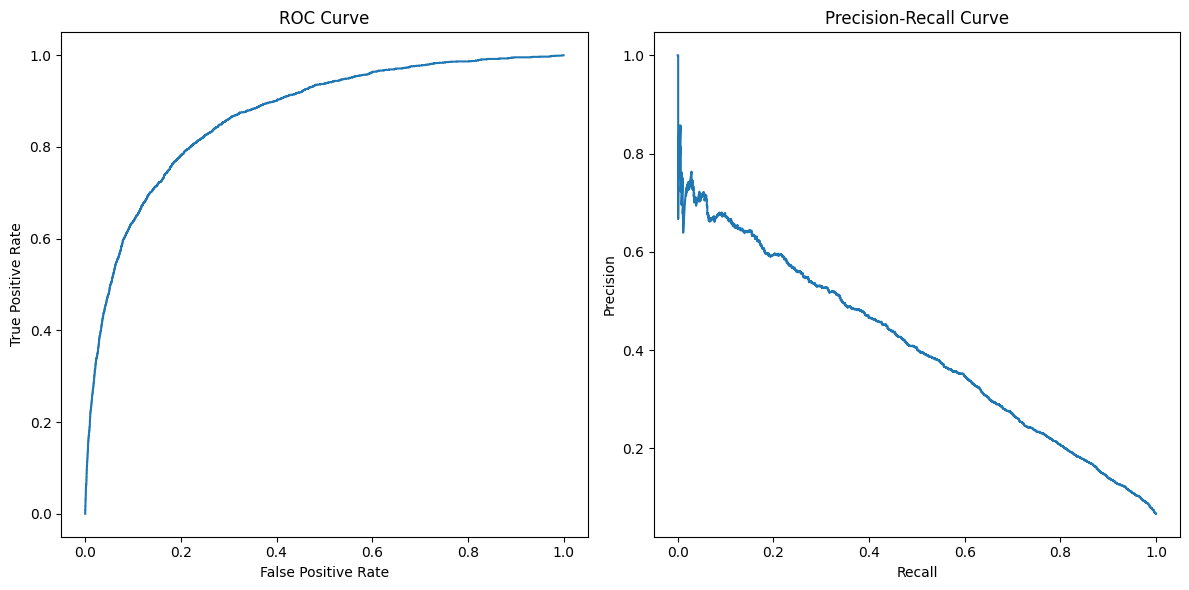

In [23]:
best_t = find_best_thershold(y_test, final_proba)

evaluate_model("Final Ensemble", y_test, final_proba, threshold=best_t)

# Cross validation

In [24]:
xgb_cv = cross_val_score(xgb, X_train, y_train, scoring='roc_auc')
print("cross val score XGBoost: ", xgb_cv)
print("cross val mean XGBoost: ", xgb_cv.mean())
print("Standard deviation XGBoost:", xgb_cv.std())
print("="*20)
lgbm_cv = cross_val_score(lgbm, X_train, y_train, scoring='roc_auc')
print("cross val score LightGBM: ", lgbm_cv)
print("cross val mean LightGBM: ", lgbm_cv.mean())
print("Standard deviation LightGBM:", lgbm_cv.std())

cross val score XGBoost:  [0.8703503  0.8619261  0.85540103 0.85849686 0.86492398]
cross val mean XGBoost:  0.862219653834037
Standard deviation XGBoost: 0.005174164280139851
cross val score LightGBM:  [0.87332053 0.86335311 0.85821134 0.86089759 0.86498114]
cross val mean LightGBM:  0.8641527414557789
Standard deviation LightGBM: 0.0051238694312167096


# Final evaluation 


====FINAL TEST (Threshold = 0.15303030303030302)====
Accuracy: 0.8445
ROC-AUC: 0.8774
Precision: 0.2624
Recall: 0.7327
F1: 0.3864
PR-AUC: 0.4297

 Classification report 

              precision    recall  f1-score   support

           0       0.98      0.85      0.91     27995
           1       0.26      0.73      0.39      2005

    accuracy                           0.84     30000
   macro avg       0.62      0.79      0.65     30000
weighted avg       0.93      0.84      0.88     30000

Confusion matrix 

[[23865  4130]
 [  536  1469]]


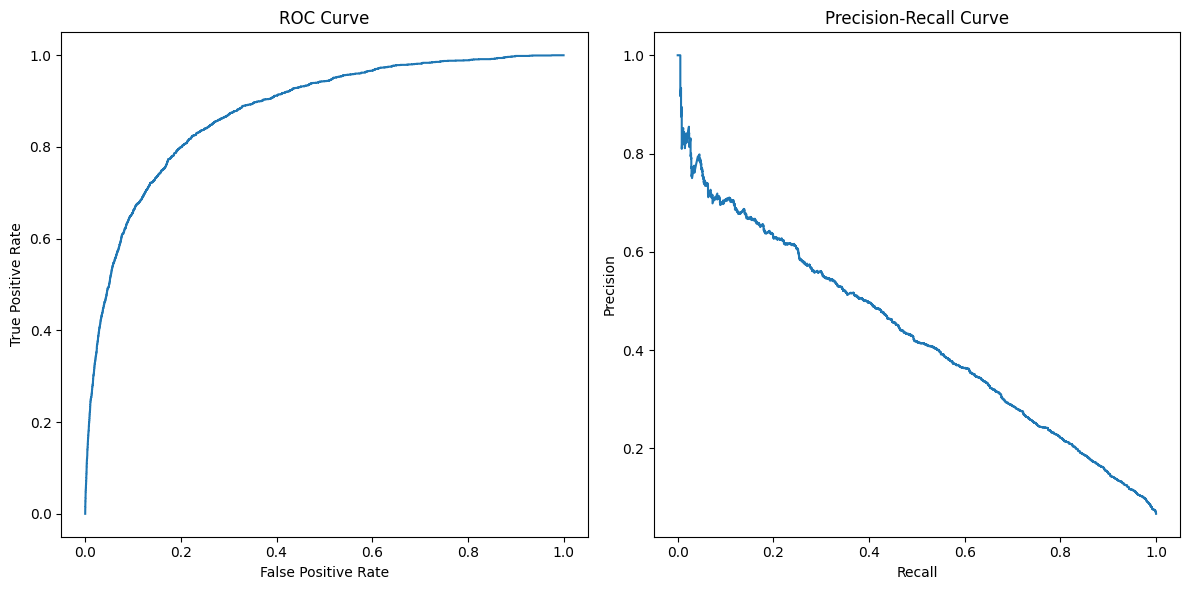

In [25]:
xgb.fit(X, y)
lgbm.fit(X, y)

xgb_proba_test = xgb.predict_proba(X_test)[:, 1]
lgb_proba_test = lgbm.predict_proba(X_test)[:, 1]

final_proba_test = 0.4 * xgb_proba_test + 0.6 * lgb_proba_test

evaluate_model("FINAL TEST", y_test, final_proba_test, threshold=best_t)

# OOF Validation

In [26]:
def get_oof_ensemble(xgb_model, lgb_model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    oof_proba = np.zeros(len(X))

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        xgb_model.fit(X_tr, y_tr)
        lgb_model.fit(X_tr, y_tr)

        xgb_p = xgb_model.predict_proba(X_val)[:, 1]
        lgb_p = lgb_model.predict_proba(X_val)[:, 1]

        oof_proba[val_idx] = 0.4 * xgb_p + 0.6 * lgb_p

    return oof_proba

In [27]:
oof_proba = get_oof_ensemble(xgb, lgbm, X, y)

150000 150000
0.020247394669522377 0.781685011434124


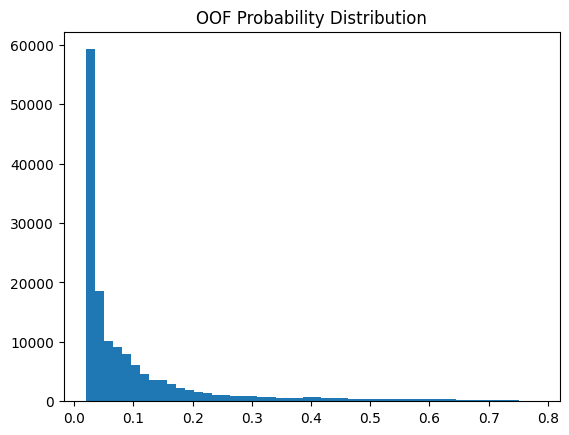

In [28]:
print(len(oof_proba), len(y))
print(oof_proba.min(), oof_proba.max())

plt.hist(oof_proba, bins=50)
plt.title("OOF Probability Distribution")
plt.show()

In [29]:
print("OOF ROC AUC:", roc_auc_score(y, oof_proba))
print("OOF PR AUC :", average_precision_score(y, oof_proba))

OOF ROC AUC: 0.8647724430205443
OOF PR AUC : 0.4032086816777647


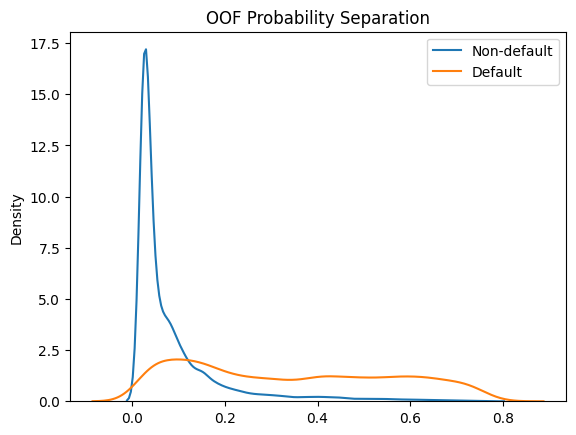

In [30]:
sns.kdeplot(oof_proba[y==0], label="Non-default")
sns.kdeplot(oof_proba[y==1], label="Default")
plt.legend()
plt.title("OOF Probability Separation")
plt.show()

In [31]:
for t in [0.2, 0.3, 0.4]:
    preds = (oof_proba >= t).astype(int)
    print(t, recall_score(y, preds))

0.2 0.6334530221424297
0.3 0.5145621384400558
0.4 0.40903650508677436


In [32]:
fold_scores = []

skfd = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in skfd.split(X, y):

    
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb.fit(X_tr, y_tr)
    lgbm.fit(X_tr, y_tr)

    xgb_p = xgb.predict_proba(X_val)[:, 1]
    lgb_p = lgbm.predict_proba(X_val)[:, 1]

    preds = 0.4 * xgb_p + 0.6 * lgb_p

    score = roc_auc_score(y_val, preds)
    fold_scores.append(score)

print("Fold AUCs:", fold_scores)

Fold AUCs: [np.float64(0.8622633118719145), np.float64(0.8644024249075473), np.float64(0.8694542532755448), np.float64(0.8590216101111752), np.float64(0.8694537188017633)]


# Calibration Curves

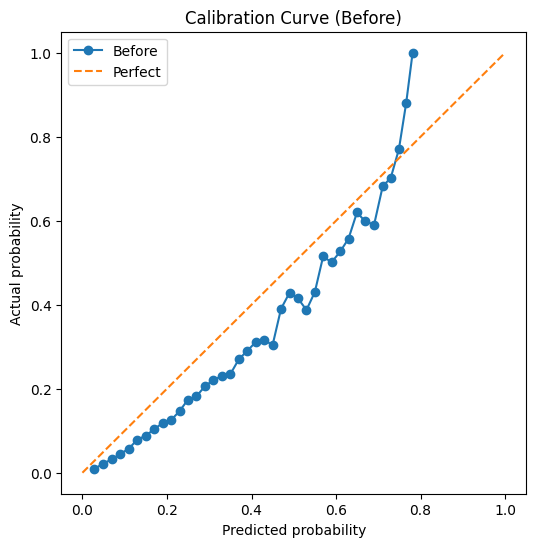

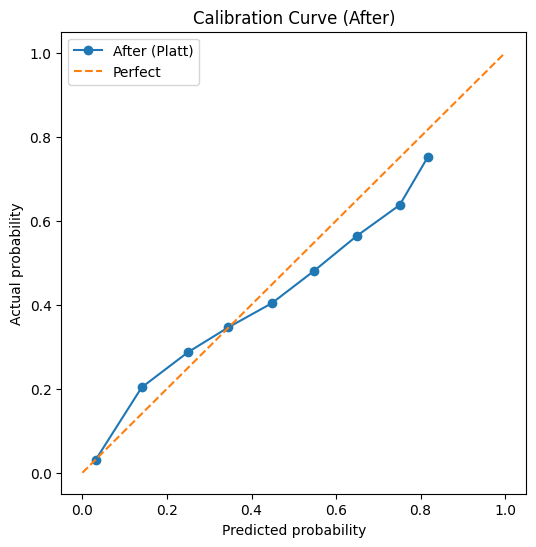

In [33]:
prob_true, prob_pred = calibration_curve(y, oof_proba, n_bins=50)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label="Before")
plt.plot([0,1], [0,1], '--', label="Perfect")

plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.title("Calibration Curve (Before)")
plt.legend()
plt.show()

platt = LogisticRegression()
platt.fit(oof_proba.reshape(-1,1), y)

cal_oof_proba = platt.predict_proba(oof_proba.reshape(-1,1))[:,1]

prob_true_cal, prob_pred_cal = calibration_curve(y, cal_oof_proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label="After (Platt)")
plt.plot([0,1], [0,1], '--', label="Perfect")

plt.xlabel("Predicted probability")
plt.ylabel("Actual probability")
plt.title("Calibration Curve (After)")
plt.legend()
plt.show()

In [34]:
print("Brier Before:", brier_score_loss(y, oof_proba))
print("Brier After :", brier_score_loss(y, cal_oof_proba))

Brier Before: 0.05104367395980707
Brier After : 0.049651585220984056


In [35]:
best_tc = find_best_thershold(y, cal_oof_proba)
print("Best threshold:", best_tc)

Best threshold: 0.05858585858585859


In [36]:
preds = (cal_oof_proba >= best_t).astype(int)

print("Recall:", recall_score(y, preds))
print("Precision:", precision_score(y, preds))

Recall: 0.504887293038101
Precision: 0.3942367601246106


# Saving the model

In [37]:
import os
import joblib
import json

In [38]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(xgb, "artifacts/xgb_model.pkl")
joblib.dump(lgbm, "artifacts/lgbm_model.pkl")

config = {
    "threshold": 0.2217171717171717,
    "weights": {
        "xgb": 0.4,
        "lgbm": 0.6
    },
    "model_version": "v1.0",
    "target": "SeriousDlqin2yrs",
    "description": "Ensemble credit risk scoring system"
}

with open("artifacts/config.json", "w") as f:
    json.dump(config, f, indent=4)

In [39]:
class CreditRiskPipeline:
    def __init__(self, path="artifacts"):

        self.xgb = joblib.load(f"{path}/xgb_model.pkl")
        self.lgbm = joblib.load(f"{path}/lgbm_model.pkl")

        with open(f"{path}/config.json") as f:
            config = json.load(f)

        self.threshold = config["threshold"]
        self.w_xgb = config["weights"]["xgb"]
        self.w_lgbm = config["weights"]["lgbm"]

    def predict_proba(self, X):
        xgb_p = self.xgb.predict_proba(X)[:, 1]
        lgbm_p = self.lgbm.predict_proba(X)[:, 1]

        return self.w_xgb * xgb_p + self.w_lgbm * lgbm_p

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba >= self.threshold).astype(int)

In [40]:
model = CreditRiskPipeline()

proba = model.predict_proba(df_test)
pred = model.predict(df_test)

print(proba, pred)

[0.12923418 0.08956203 0.02889922 ... 0.02151764 0.16536981 0.0955269 ] [0 0 0 ... 0 0 0]
